## Import necessary libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Load the color image

In [5]:
image = cv2.imread("./web_images_processed_versions/web_image.png")

In [6]:
if image is None:
    raise FileNotFoundError(f"The image at {image_path} could not be found. Please check the path.")

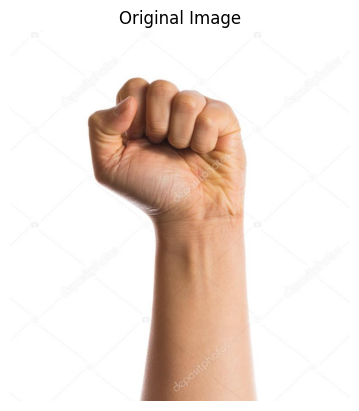

In [7]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')
plt.show()

## Convert the image to grayscale

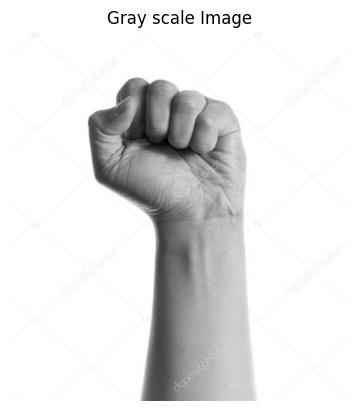

In [8]:
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(gray_image, cmap='gray')
plt.title('Gray scale Image')
plt.axis('off')
plt.show()

## Apply Gaussian blur to reduce noise

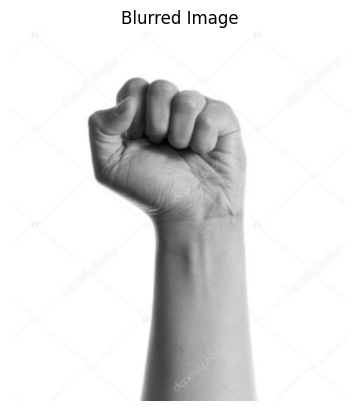

In [9]:
blurred_image = cv2.GaussianBlur(gray_image, (5, 5), 0)

plt.imshow(blurred_image, cmap='gray')
plt.title('Blurred Image')
plt.axis('off')
plt.show()

## Enhance contrast and use binary threadholding to simulate infrared-like features 
Apply Histogram Equalization to enhance contrast

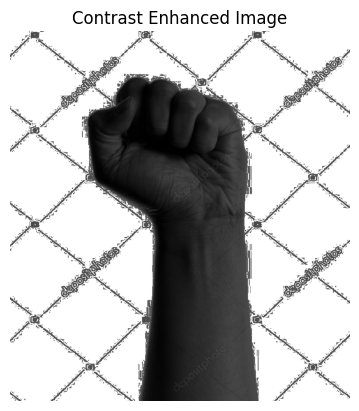

In [10]:
equalized_image = cv2.equalizeHist(gray_image)

plt.imshow(equalized_image, cmap='gray')
plt.title('Contrast Enhanced Image')
plt.axis('off')
plt.show()

Use binary thresholding

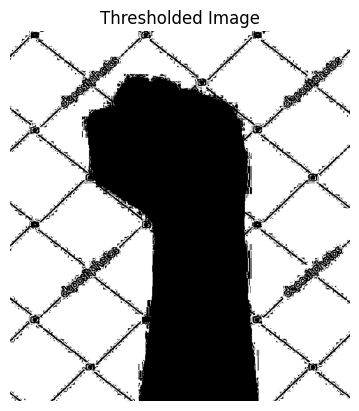

In [11]:
_, thresholded_image = cv2.threshold(
    equalized_image,
    100,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

plt.imshow(thresholded_image, cmap='gray')
plt.title('Thresholded Image')
plt.axis('off')
plt.show()

## Apply morphological operations (optional)

This can help to remove small noises or fill in small holes in the hand region

In [12]:
kernel = np.ones((5, 5), np.uint8)
morphed_image = cv2.morphologyEx(
    thresholded_image,
    cv2.MORPH_CLOSE,
    kernel 
)

Apply an additional erosion to further remove noise

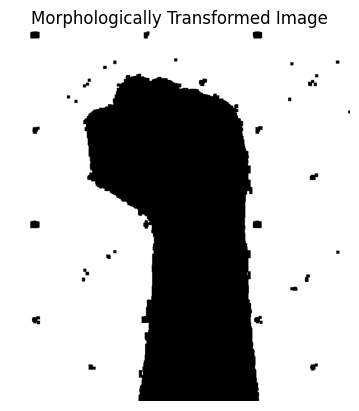

In [13]:
kernel_erode = np.ones((3, 3), np.uint8)
morphed_image = cv2.erode(
    morphed_image,
    kernel_erode,
    iterations=1
)


plt.imshow(morphed_image, cmap='gray')
plt.title('Morphologically Transformed Image')
plt.axis('off')
plt.show()

Apply a more strict threadholding to remove background completely

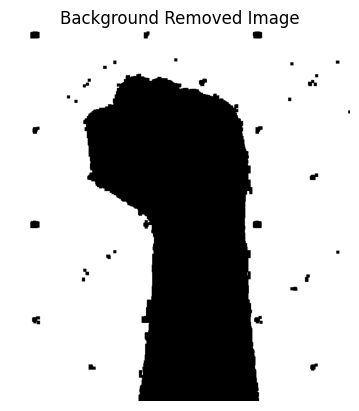

In [14]:
_, morphed_image = cv2.threshold(
    morphed_image,
    127,
    255,
    cv2.THRESH_BINARY
)

plt.imshow(morphed_image, cmap='gray')
plt.title('Background Removed Image')
plt.axis('off')
plt.show()

Find contours and draw them on the original grayscale image

In [15]:
contours, _ = cv2.findContours(
    morphed_image,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

Filter out small contours by area

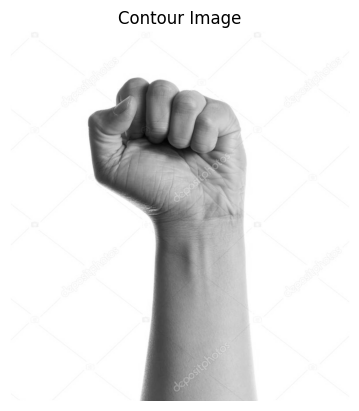

In [16]:
filtered_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > 1000]

contour_image = gray_image.copy()
cv2.drawContours(
    contour_image,
    filtered_contours,
    -1,
    (255, 255, 255),
    2
)

plt.imshow(contour_image, cmap='gray')
plt.title('Contour Image')
plt.axis('off')
plt.show()